In [1]:
"""
Во время финансовых кризисов (2008, 2020) инвесторы сталкиваются с феноменом Contagion (эффект заражения). 
В обычное время акции IT-сектора и акции нефтяных компаний могут двигаться независимо. 
Но когда наступает шок (например, крах Lehman Brothers), корреляция всех активов стремится к единице (все падает одновременно).

Почему так происходит? Из-за механизма "Fire Sales" (Вынужденные распродажи).
Представьте крупный хедж-фонд, который терпит гигантские убытки из-за обвала технологического сектора. 
Брокер требует от фонда внести дополнительное обеспечение (Margin Call). Где фонду взять наличные? 
Он вынужден экстренно продавать "хорошие" активы (нефтянку, золото, гособлигации). 
Из-за этих распродаж падают цены активов, которые изначально вообще не были связаны с кризисом. 
Шок передается по рынку, как вирус.

Наша задача на семинаре:

Топология рынка: Мы возьмем 30 крупнейших компаний США из разных секторов и построим матрицу их корреляций во 
время Ковидного шока (весна 2020).
Фильтрация шума (Graph Theory): Матрица 30x30 — это 900 связей. Анализировать её невозможно. 
Мы применим теорию графов: превратим корреляцию в математическое расстояние и построим 
MST (Minimal Spanning Tree / Минимальное остовное дерево). 
Это выявит "хребет" рынка — узловые компании, через которые передается системный риск.
Стресс-тест: Мы напишем симулятор. Что будет с портфелем, 
если акция Apple завтра рухнет на 15%? 
Мы рассчитаем волну падения по всем остальным акциям, используя статистический аппарат условной регрессии.
Источник данных:
API yfinance (Yahoo Finance). Это бесплатная библиотека, которая напрямую скачивает биржевые данные.
Мы будем использовать Adjusted Close (Скорректированная цена закрытия), 
так как она учитывает выплату дивидендов и сплиты акций (что критически важно для корректного расчета доходности).
"""

_IncompleteInputError: incomplete input (969763094.py, line 1)

[*********************100%***********************]  30 of 30 completed

Скачиваем данные с Yahoo Finance...


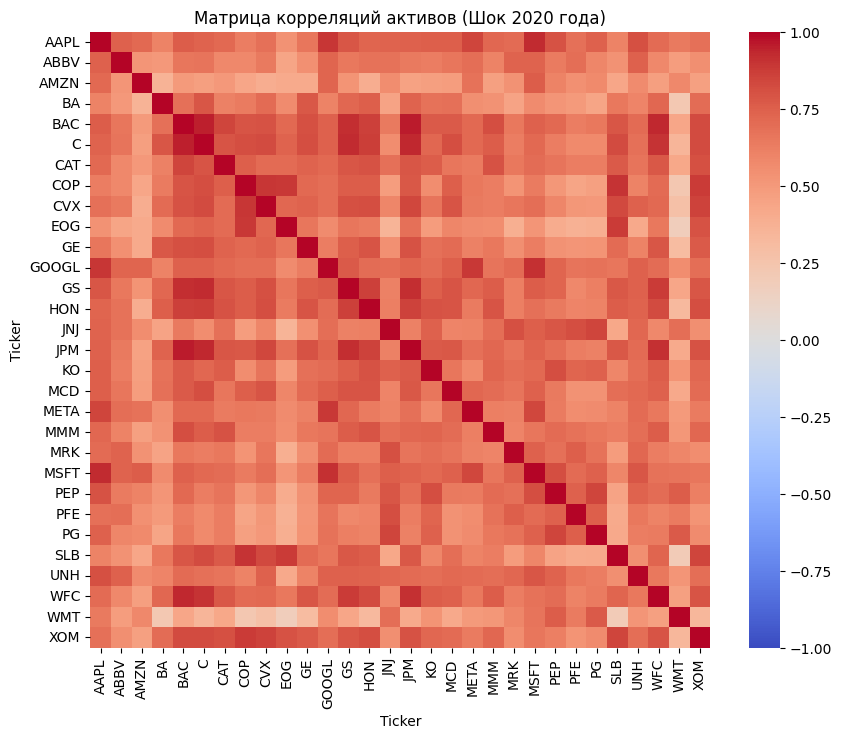

In [20]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Топ-30 компаний из разных секторов (Tech, Finance, Healthcare, Energy, Consumer)
tickers =[
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META',          # Tech
    'JPM', 'BAC', 'WFC', 'C', 'GS',                   # Finance
    'JNJ', 'PFE', 'UNH', 'ABBV', 'MRK',               # Healthcare
    'XOM', 'CVX', 'COP', 'SLB', 'EOG',                # Energy
    'WMT', 'PG', 'KO', 'PEP', 'MCD',                  # Consumer
    'BA', 'CAT', 'MMM', 'GE', 'HON'                   # Industrials
]

print("Скачиваем данные с Yahoo Finance...")
# Скачиваем данные за период Ковидного шока (январь - июнь 2020)
data = yf.download(tickers, start="2020-01-01", end="2020-06-30")['Close']
# Если yfinance вернул мультииндекс, убираем лишнее, оставляем только тикеры
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)
data.head()
# # TODO 1.1: Рассчитайте ежедневные логарифмические доходности (Log Returns).
# # Подсказка: Формула лог-доходности: r_t = ln(P_t / P_{t-1}).
# # Используйте np.log() и метод .shift(1) или метод .diff().
# # Удалите первую строку (там будет NaN).
returns = np.log(data / data.shift(1))
returns = returns.drop('2020-01-02')

# # TODO 1.2: Рассчитайте матрицу корреляций Пирсона для доходностей.
# # Используйте встроенный метод pandas.
corr_matrix = returns.corr()

# # Визуализация тепловой карты корреляций (готовый код)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Матрица корреляций активов (Шок 2020 года)')
plt.show()


In [21]:
!pip3 install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 3.5 MB/s eta 0:00:00a 0:00:01


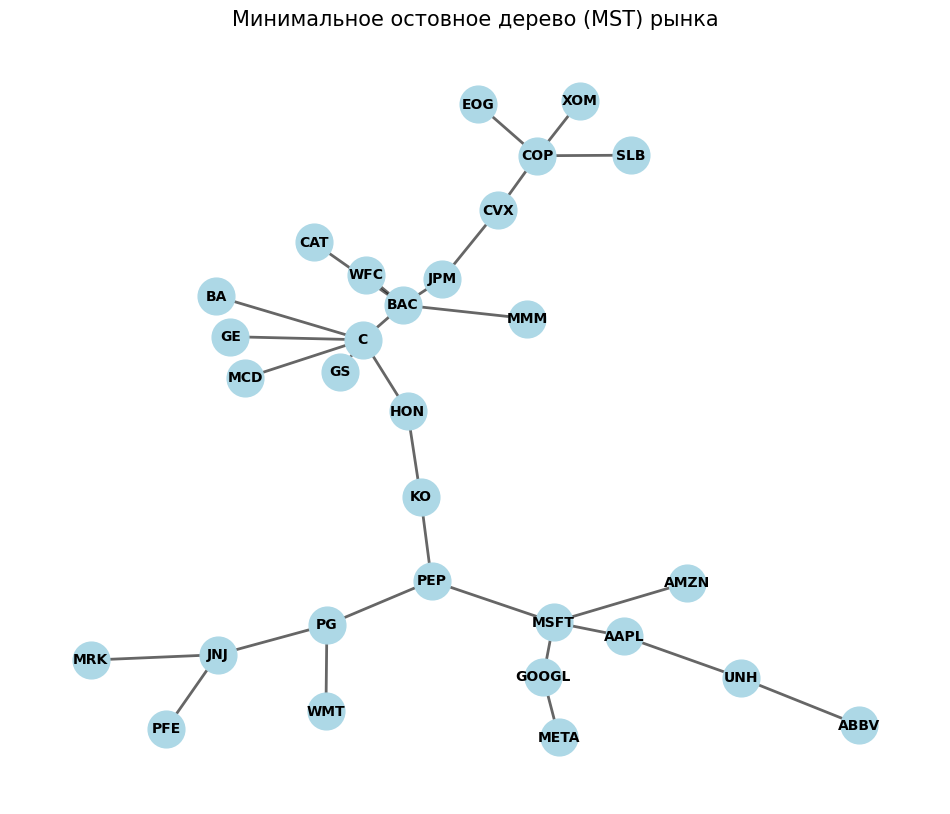

In [30]:
import networkx as nx

# TODO 2.1: Трансформируйте матрицу корреляций в матрицу дистанций.
# Классическая финансовая формула: D = sqrt(2 * (1 - Correlation))
# Используйте np.sqrt(). Обратите внимание, что мы работаем с матрицей (DataFrame).
distance_matrix = np.sqrt(2 * (1 - corr_matrix))

# Создаем пустой ненаправленный граф
G = nx.Graph()
distance_matrix.columns
# TODO 2.2: Заполните граф вершинами и ребрами.
# Напишите двойной цикл (по строкам и колонкам distance_matrix).
# Добавляйте ребро между тикерами (G.add_edge), только если это разные тикеры (i != j).
# В качестве атрибута 'weight' передавайте значение дистанции из матрицы.
for i in distance_matrix.columns:
    for j in distance_matrix.columns:
        if i != j:
            G.add_edge(i, j, weight=distance_matrix.loc[i][j])

# # TODO 2.3: Постройте Минимальное остовное дерево (MST).
# # Используйте функцию nx.minimum_spanning_tree() от вашего графа G.
mst = nx.minimum_spanning_tree(G)

# Визуализация MST (Код готов, так как настройка графов занимает много времени)
plt.figure(figsize=(12, 10))
# Располагаем узлы так, чтобы тесно связанные были рядом (Kamada Kawai layout)
pos = nx.kamada_kawai_layout(mst)

# Рисуем узлы и ребра
nx.draw_networkx_nodes(mst, pos, node_size=700, node_color='lightblue')
nx.draw_networkx_edges(mst, pos, width=2, alpha=0.6)
nx.draw_networkx_labels(mst, pos, font_size=10, font_family="sans-serif", font_weight='bold')

plt.title('Минимальное остовное дерево (MST) рынка', fontsize=15)
plt.axis('off')
plt.show()

# Дискуссия с группой:
# Посмотрите на граф. Видите ли вы секторальные кластеры? 
# Кто находится в самом центре графа (Hub)? Именно через эти акции шок распространяется на остальные сектора.


In [25]:
distance_matrix

Ticker,AAPL,ABBV,AMZN,BA,BAC,C,CAT,COP,CVX,EOG,...,MRK,MSFT,PEP,PFE,PG,SLB,UNH,WFC,WMT,XOM
Ticker,,,,,,,,,,,,,,,,,,,,,
AAPL,0.000000,0.716345,0.750121,0.891377,0.686446,0.723985,0.752771,0.861433,0.799125,0.960696,...,0.769813,0.379070,0.625676,0.793337,0.710724,0.885213,0.624615,0.768050,0.843104,0.799759
ABBV,0.716345,0.000000,0.981960,0.997514,0.825609,0.812952,0.914922,0.917872,0.843024,1.056036,...,0.723174,0.720941,0.849675,0.789673,0.908906,0.964861,0.716020,0.917029,1.016084,0.944329
AMZN,0.750121,0.981960,0.000000,1.131249,1.005790,1.025909,0.996311,1.067039,1.100648,1.087383,...,0.965477,0.686242,0.889597,0.956106,0.923420,1.063382,0.929465,1.027843,0.917943,1.037834
BA,0.891377,0.997514,1.131249,0.000000,0.792076,0.660379,0.878026,0.851565,0.770185,0.934478,...,1.046044,0.929256,0.982048,1.002715,1.058302,0.832027,0.900818,0.749311,1.249406,0.780136
BAC,0.686446,0.825609,1.005790,0.792076,0.000000,0.327315,0.558884,0.643145,0.625483,0.759530,...,0.831169,0.716093,0.751235,0.862817,0.833942,0.650956,0.760595,0.358434,1.063402,0.588892
C,0.723985,0.812952,1.025909,0.660379,0.327315,0.000000,0.648463,0.602283,0.592232,0.727018,...,0.863915,0.754725,0.860385,0.923305,0.926052,0.593827,0.792006,0.441063,1.143509,0.597611
CAT,0.752771,0.914922,0.996311,0.878026,0.558884,0.648463,0.000000,0.702456,0.765585,0.760852,...,0.831062,0.777232,0.812216,0.865888,0.858251,0.681532,0.815781,0.662911,1.070502,0.620722
COP,0.861433,0.917872,1.067039,0.851565,0.643145,0.602283,0.702456,0.000000,0.462374,0.470643,...,0.972299,0.850865,0.990102,1.056368,1.035473,0.449236,0.890870,0.761053,1.240203,0.493608
CVX,0.799125,0.843024,1.100648,0.770185,0.625483,0.592232,0.765585,0.462374,0.000000,0.743038,...,0.829054,0.787356,0.909256,0.988189,0.998836,0.574842,0.717155,0.753510,1.202961,0.538865


In [ ]:
# TODO 3.1: Рассчитайте вектор стандартных отклонений (волатильностей) для всех активов.
# Используйте метод .std() к датафрейму returns.
volatilities = # <ВАШ_КОД>

# Задаем параметры шока
shocked_asset = 'AAPL'  # Акция, с которой начался кризис
shock_value = -0.10     # Падение на 10%

# Создаем пустой словарь для записи того, как упадут остальные активы
contagion_effects = {}

# TODO 3.2: Напишите цикл для расчета ожидаемого падения каждого актива.
# Пройдитесь циклом по всем тикерам (target_asset) в списке tickers.
# Если target_asset == shocked_asset, его падение равно shock_value.
# Для остальных:
# 1. Извлеките корреляцию между shocked_asset и target_asset из corr_matrix.
# 2. Вычислите бету по математической формуле: Beta = Correlation * (Sigma_target / Sigma_shocked).
# 3. Рассчитайте ожидаемую доходность: Expected_Return = Beta * shock_value.
for target_asset in tickers:
    if target_asset == shocked_asset:
        contagion_effects[target_asset] = shock_value
    else:
        # <ВАШ_КОД: Извлечение корреляции>
        correlation = # <ВАШ_КОД>
        
        # <ВАШ_КОД: Расчет беты>
        beta = # <ВАШ_КОД>
        
        # <ВАШ_КОД: Расчет ожидаемого падения>
        expected_return = # <ВАШ_КОД>
        
        contagion_effects[target_asset] = expected_return

# Превращаем словарь в DataFrame и сортируем для красоты
shock_df = pd.DataFrame.from_dict(contagion_effects, orient='index', columns=['Expected_Return'])
shock_df = shock_df.sort_values(by='Expected_Return')

# Визуализация результатов стресс-теста
plt.figure(figsize=(12, 6))
# Выделим источник шока красным цветом
colors =['red' if x == shocked_asset else 'steelblue' for x in shock_df.index]
sns.barplot(x=shock_df.index, y=shock_df['Expected_Return'] * 100, palette=colors)
plt.title(f'Стресс-тест: Эффект заражения при падении {shocked_asset} на {shock_value*100}%')
plt.ylabel('Ожидаемое изменение цены (%)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--')
plt.show()
